`02_data_visualization.ipynb`: Visualización de datos y transformación a formato YOLO.

# Importaciones

In [1]:
import os
from pathlib import Path
import cv2 

from dataset.scanner import scan_raw_dataset
from dataset.analyzer import parse_annotations
from dataset.yolo_converter import process_video_to_yolo
from utils.file_utils import load_gt
from visualization.visualize import draw_raw_annotations, plot_image, visualize_yolo_label
from visualization.visualize import plot_video_frames_grid, export_annotated_video
PROJECT_ROOT = Path().resolve().parent
CONFIG_PATH = PROJECT_ROOT / "paths.yaml"

In [2]:
ds_info = scan_raw_dataset(CONFIG_PATH)

# Visualización Datos Originales

Seleccionamos un ejemplo y mostramos las anotaciones originales sobre un frame.

In [3]:
example = ds_info['data']['horse'][0]
video_path = example['video']
label_path = example['label']

gt_raw = load_gt(label_path)
gt_data = parse_annotations(gt_raw)

Seleccionamos un frame específico del vídeo

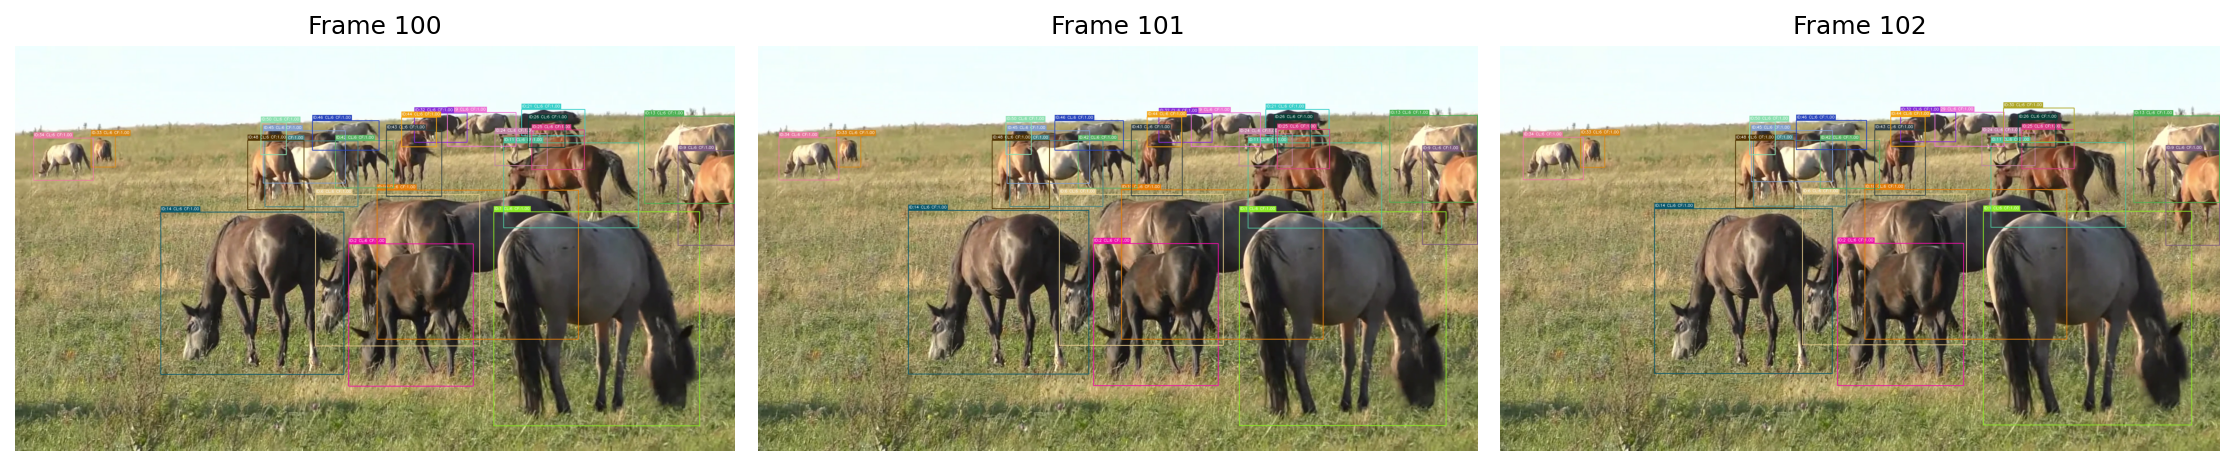

In [4]:
plot_video_frames_grid(
    video_path=video_path, 
    start_frame=100, 
    n_frames=3, 
    annotations=gt_data
)

Exportación de un vídeo anotado

In [5]:
out_video_dir = Path("docs/videos")
out_video_path = out_video_dir / f"{Path(video_path).stem}_annotated.mp4"

export_annotated_video(
    video_path=video_path,
    annotations=gt_data,
    output_path=out_video_path
)

Success: Annotated video saved to docs/videos/horse_1_annotated.mp4


# Transformación a YOLO

El dataset original (`dataset/raw`) contiene videos `.mp4` y anotaciones en texto plano. 
El formato de estas etiquetas originales es:

`[frame_id, target_id, top_left_x, top_left_y, width, confidence, class, visibility]`

YOLO requiere un formato muy específico:
- Una carpeta para imágenes (`processed/images`) y otra para etiquetas (`processed/labels`).
- Un archivo `.txt` por cada imagen (frame).
- Las coordenadas deben estar normalizadas entre [0, 1] y seguir el formato:

`[class_id, x_center, y_center, width, height]`

Para solucionar esto, aplicaremos la función `process_video_to_yolo`, la cual iterará sobre cada vídeo, extraerá sus frames y calculará las coordenadas relativas al tamaño del frame.

In [6]:
classes_dict = ds_info['classes'] # Viene del paths.yaml
id_map = {}
for yolo_index, (name, original_id) in enumerate(classes_dict.items()):
    id_map[original_id] = yolo_index
    
print(f"Mapa de IDs aplicado: {id_map}")

Mapa de IDs aplicado: {6: 0, 7: 1, 8: 2}


In [ ]:
import gc

print(f"Ruta de destino: {ds_info['processed_path']}")

# Iteramos sobre las clases definidas en paths.yaml
for class_name in ds_info['classes'].keys():
    print(f"\n> Procesando clase: {class_name.upper()}")
    
    lista_videos = ds_info['data'][class_name]
    
    for i, item in enumerate(lista_videos):
        video_path = item['video']
        label_path = item['label']
        
        base_name = Path(video_path).stem

        output_images = ds_info['processed_path'] / 'images' / base_name
        output_labels = ds_info['processed_path'] / 'labels' / base_name
        
        process_video_to_yolo(
            video_path=video_path, 
            gt_path=label_path, 
            output_img_dir=output_images, 
            output_lbl_dir=output_labels,
            class_map=id_map,
            frame_step=20
        )
        gc.collect() 

Ruta de destino: /home/cgonzalez/Object_Recognition/dataset/processed

> Procesando clase: HORSE
Successfully processed horse_1.mp4: 11 frames saved.
Successfully processed horse_2.mp4: 12 frames saved.
Successfully processed horse_3.mp4: 57 frames saved.
Successfully processed horse_4.mp4: 8 frames saved.
Successfully processed horse_5.mp4: 13 frames saved.
Successfully processed horse_6.mp4: 12 frames saved.
Successfully processed horse_7.mp4: 52 frames saved.

> Procesando clase: PENGUIN
Successfully processed penguin_1.mp4: 12 frames saved.
Successfully processed penguin_2.mp4: 13 frames saved.
Successfully processed penguin_3.mp4: 12 frames saved.
Successfully processed penguin_4.mp4: 13 frames saved.
Successfully processed penguin_5.mp4: 12 frames saved.
Successfully processed penguin_6.mp4: 9 frames saved.

> Procesando clase: PIG
Successfully processed pig_1.mp4: 12 frames saved.
Successfully processed pig_2.mp4: 12 frames saved.
Successfully processed pig_3.mp4: 12 frames save

## Visualizacción de los ejemplos de YOLO

In [8]:
class_names = {v: k for k, v in ds_info['classes'].items()} 

test_base = ds_info['data']['horse'][0]['video'].stem

test_img_path = ds_info['processed_path'] / 'images' / test_base / f"{test_base}_frame_10.jpg"
test_lbl_path = ds_info['processed_path'] / 'labels' / test_base / f"{test_base}_frame_10.txt"

print(f"Comprobando imagen: {test_img_path}")
print(f"Comprobando etiqueta: {test_lbl_path}\n")
visualize_yolo_label(
    image_path=test_img_path, 
    label_path=test_lbl_path, 
    class_names=class_names
)

Comprobando imagen: /home/cgonzalez/Object_Recognition/dataset/processed/images/horse_1/horse_1_frame_10.jpg
Comprobando etiqueta: /home/cgonzalez/Object_Recognition/dataset/processed/labels/horse_1/horse_1_frame_10.txt

Error: Image not found at /home/cgonzalez/Object_Recognition/dataset/processed/images/horse_1/horse_1_frame_10.jpg
